In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data
from faraway.datasets import galapagos

In [2]:
# Load the data
data = galapagos.load()

# Inspect the data
print(data.head())
print(data.info())

           Species   Area  Elevation  Nearest  Scruz  Adjacent
Baltra          58  25.09        346      0.6    0.6      1.84
Bartolome       31   1.24        109      0.6   26.3    572.33
Caldwell         3   0.21        114      2.8   58.7      0.78
Champion        25   0.10         46      1.9   47.4      0.18
Coamano          2   0.05         77      1.9    1.9    903.82
<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, Baltra to Wolf
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Species    30 non-null     int64  
 1   Area       30 non-null     float64
 2   Elevation  30 non-null     int64  
 3   Nearest    30 non-null     float64
 4   Scruz      30 non-null     float64
 5   Adjacent   30 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 1.6+ KB
None


In [3]:
# Define predictors and response variable
X = data[['Area', 'Elevation', 'Nearest']]  # Example predictors
y = data['Species']  # Response (binary outcome: presence/absence)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

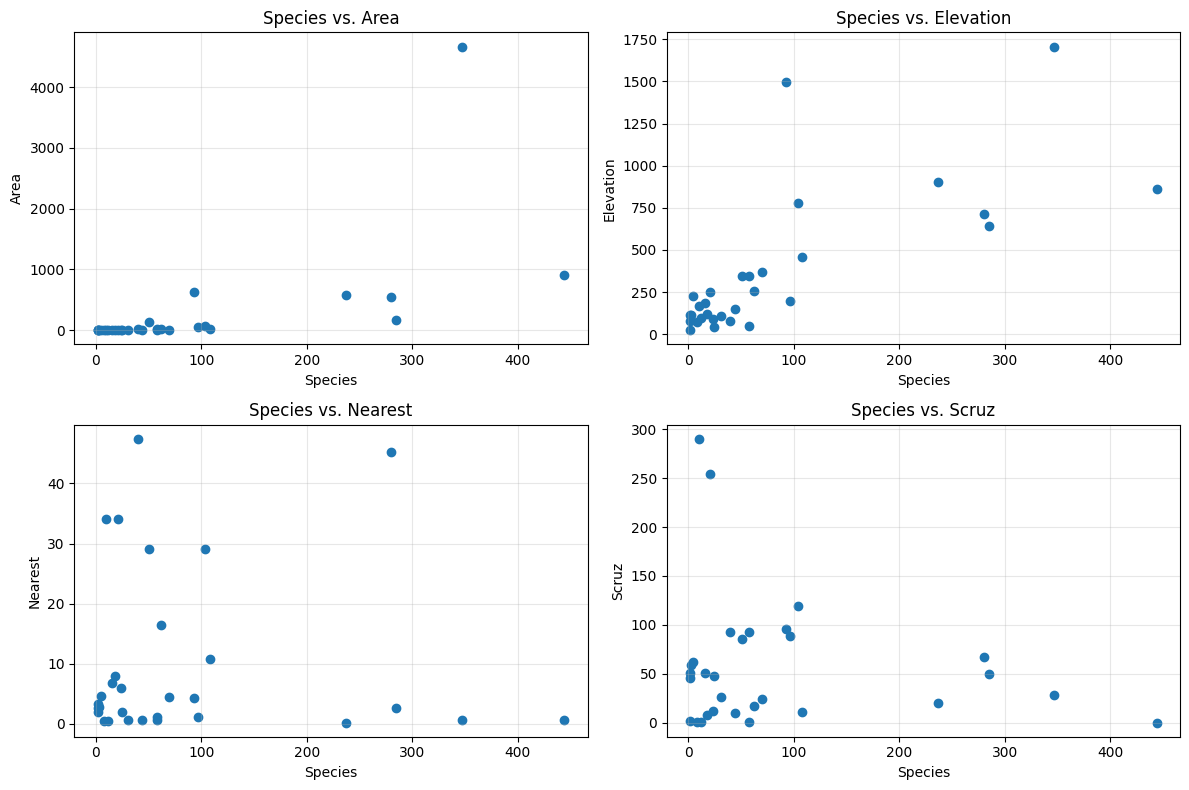

In [4]:
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot Species vs. Area
axes[0, 0].scatter(data['Species'], data['Area'])
axes[0, 0].set_xlabel('Species')
axes[0, 0].set_ylabel('Area')
axes[0, 0].set_title('Species vs. Area')
axes[0,0].grid(alpha=0.3)

# Plot Species vs. Elevation
axes[0, 1].scatter(data['Species'], data['Elevation'])
axes[0, 1].set_xlabel('Species')
axes[0, 1].set_ylabel('Elevation')
axes[0, 1].set_title('Species vs. Elevation')
axes[0, 1].grid(alpha=0.3)


# Plot Species vs. Nearest
axes[1, 0].scatter(data['Species'], data['Nearest'])
axes[1, 0].set_xlabel('Species')
axes[1, 0].set_ylabel('Nearest')
axes[1, 0].set_title('Species vs. Nearest')
axes[1,0].grid(alpha=0.3)


# Plot Species vs. Scruz
axes[1, 1].scatter(data['Species'], data['Scruz'])
axes[1, 1].set_xlabel('Species')
axes[1, 1].set_ylabel('Scruz')
axes[1, 1].set_title('Species vs. Scruz')
axes[1,1].grid(alpha=0.3)


plt.tight_layout()  # Adjust spacing between subplots
plt.show()

In [5]:
# Define predictors and response variable
X = data[['Area', 'Elevation', 'Adjacent']]  # Example predictors

# Calculate the median of the Nearest column
median_nearest = data['Nearest'].median()

# Create the Nearest_Binary column
y= data['Nearest_Binary'] = (data['Nearest'] > median_nearest).astype(int)

# Inspect the new column
print(data[['Nearest', 'Nearest_Binary']].head(8))

              Nearest  Nearest_Binary
Baltra            0.6               0
Bartolome         0.6               0
Caldwell          2.8               0
Champion          1.9               0
Coamano           1.9               0
Daphne.Major      8.0               1
Daphne.Minor      6.0               1
Darwin           34.1               1


In [6]:
# Count the occurrences of 0 and 1
binary_counts = y.value_counts()

# Print the counts
print("Counts of 0 and 1 in Nearest_Binary:")
print(binary_counts)

Counts of 0 and 1 in Nearest_Binary:
Nearest
0    15
1    15
Name: count, dtype: int64


In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("X_train dimensions:", X_train.shape)
print("X_test dimensions:", X_test.shape)
print("y_train dimensions:", y_train.shape)
print("y_test dimensions:", y_test.shape)

X_train dimensions: (24, 3)
X_test dimensions: (6, 3)
y_train dimensions: (24,)
y_test dimensions: (6,)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Get dimensions
print("Dimensions of X_train_scaled:", X_train_scaled.shape)
print("Dimensions of X_test_scaled:", X_test_scaled.shape)

Dimensions of X_train_scaled: (24, 3)
Dimensions of X_test_scaled: (6, 3)


In [9]:
# Fit logistic regression model on scaled data
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Output coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [0.36853881]
Coefficients: [[-0.54318024  0.75656123  0.05697516]]


In [10]:
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1
y_pred = model.predict(X_test_scaled)  # Predicted classes

# Display predictions
print("Predicted Probabilities:", y_pred_prob[:5])
print("Predicted Classes:", y_pred[:5])

Predicted Probabilities: [0.54407974 0.00074678 0.63293308 0.4764621  0.50250907]
Predicted Classes: [1 0 1 0 1]


In [11]:
# Evaluate model performance
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[1 4]
 [1 0]]
Accuracy Score: 0.16666666666666666
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.20      0.29         5
           1       0.00      0.00      0.00         1

    accuracy                           0.17         6
   macro avg       0.25      0.10      0.14         6
weighted avg       0.42      0.17      0.24         6



In [12]:
# Check multicollinearity using VIF
vif = pd.DataFrame()
vif["Variable"] = X_train.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled, i) for i in range(X_train_scaled.shape[1])]
print(vif)

    Variable       VIF
0       Area  2.814390
1  Elevation  4.149119
2   Adjacent  1.891136
